In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('US_Accidents_March23.csv')
print('The Dataset contains:\nRows: {:,d}\nColumns: {}'.format(df.shape[0], df.shape[1]))

The Dataset contains:
Rows: 7,728,394
Columns: 46


In [3]:
df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='str')

In [4]:
df.Start_Time.head()

0    2016-02-08 05:46:00
1    2016-02-08 06:07:59
2    2016-02-08 06:49:27
3    2016-02-08 07:23:34
4    2016-02-08 07:39:07
Name: Start_Time, dtype: str

In [5]:
df.End_Time.sample(10)

3584722    2017-04-12 14:43:08
7512009    2018-07-17 05:21:32
4830012    2022-04-22 19:33:23
7622149    2017-10-14 10:18:22
6932803    2020-05-26 17:04:01
2312926    2019-01-07 18:02:43
6099449    2021-08-19 20:21:56
6290882    2021-12-10 19:49:31
5191592    2022-02-11 18:53:59
118717     2016-12-18 17:03:27
Name: End_Time, dtype: str

In [6]:
df.Start_Time = df.Start_Time.str.split('.').str[0]
df.End_Time = df.End_Time.str.split('.').str[0]

In [7]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'],format = "%Y-%m-%d %H:%M:%S")
df.End_Time = pd.to_datetime(df.End_Time, format = "%Y-%m-%d %H:%M:%S")

In [8]:
df.Start_Time.dtype

dtype('<M8[us]')

## City

In [9]:
df.City.unique()

<StringArray>
[                      'Dayton',                 'Reynoldsburg',
                 'Williamsburg',                  'Westerville',
                     'Columbus',                   'Miamisburg',
                    'Johnstown',                       'Dublin',
             'Canal Winchester',                      'Lebanon',
 ...
                      'Leadore',                   'Vallecitos',
                    'Guildhall',              'Sandy River Plt',
                       'Lublin',                     'Fairbank',
                    'Pond Eddy',                    'Ness City',
                   'Clarksdale', 'American Fork-Pleasant Grove']
Length: 13679, dtype: str

In [10]:
df.City.nunique()

13678

In [11]:
city_df = pd.DataFrame(df.City.value_counts()).reset_index().rename(columns = {'count':'Cases'})
city_df.head(10)

,City,Cases
0,Miami,186917
1,Houston,169609
2,Los Angeles,156491
3,Charlotte,138652
4,Dallas,130939
5,Orlando,109733
6,Austin,97359
7,Raleigh,86079
8,Nashville,72930
9,Baton Rouge,71588


<Axes: title={'center': 'Top 10 cities with the most cases'}, xlabel='City'>

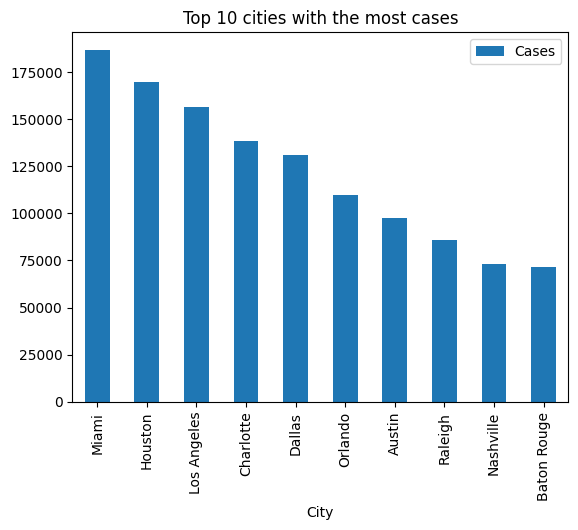

In [12]:
city_df.head(10).plot(
    kind = "bar",
    x = 'City',
    y = 'Cases',
    title = 'Top 10 cities with the most cases'
    )

In [13]:
total = sum(city_df.Cases)
total10 = sum(city_df.Cases.head(10)) / total * 100
round(total10,2)

15.79

In [14]:
for i in city_df.head(10).Cases:
    result = round(i / sum(city_df.Cases) * 100, 2)
    print(result)

2.42
2.19
2.02
1.79
1.69
1.42
1.26
1.11
0.94
0.93


#### Top 10 city accounted for 15.79% of all accidents.
top 1: Miami accounted for 2.42% of all accidents

In [15]:
print(round(sum(city_df.Cases)/7))
print(round(sum(city_df.Cases)/(7*365)))
print(round(city_df.Cases[0]/7))
print(round(city_df.Cases[0]/(7*365)))

1104020
3025
26702
73


In [16]:
round(3025/24)
round(73/2)

36

<p>Average in 7 years time, America have 1,104,020 accident cases every year
<p>About 126 accidents happen every hour in US
<p>In Miami, 26,702 accidents happen yearly
<p>About 36 accidents happen every 12 hours

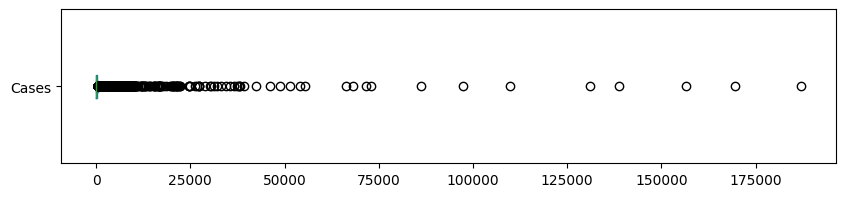

In [17]:
city_df.Cases.plot(kind = 'box', vert = False, figsize=(10,2))
plt.show()

In [18]:
city_df.Cases.describe()

count     13678.000000
mean        565.005191
std        4147.357347
min           1.000000
25%           6.000000
50%          35.000000
75%         201.000000
max      186917.000000
Name: Cases, dtype: float64

In [19]:
def percentage(value,operator):
    if operator == '=':
        result = city_df[city_df.Cases == value].shape[0]
    elif operator == '<':
        result = city_df[city_df.Cases < value].shape[0]
    elif operator ==  '>':
        result = city_df[city_df.Cases > value].shape[0]
    print(f'{result} Cities, {round((result / city_df.shape[0])*100, 2)}%')

percentage(1, '=')
percentage(202, '<')
percentage(1000, '<')
percentage(1000, '>')
percentage(5000, '>')
percentage(10000, '>')

1023 Cities, 7.48%
10265 Cities, 75.05%
12460 Cities, 91.1%
1215 Cities, 8.88%
231 Cities, 1.69%
105 Cities, 0.77%


<p>There are 1023 Cities with one 1 accident in 7 years span
<p>75% (10,265 cities) of all cities has less than 202 accident cases
<p>91.1% (12,460 cities) of all cities has less than 1000 accident cases
<p>8.88% (1215 cities) of all cities has more than 1000 accident cases
<p>1.69% (231 cities) of all cities has more than 5000 accident cases
<p>0.77% (105 cities) of all cities has more than 10000 accident cases

## Severity

In [20]:
severity_df = pd.DataFrame(df.Severity.value_counts())
severity_df = severity_df.rename(columns={'count': 'Cases'})
severity_df.head()

,Cases
Severity,
2,6156981
3,1299337
4,204710
1,67366


<Axes: >

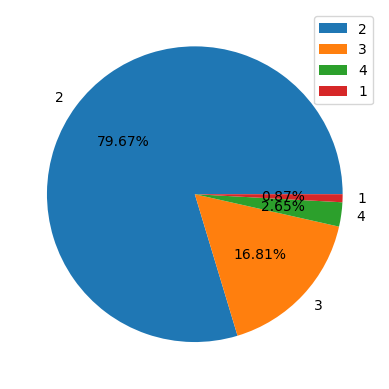

In [21]:
severity_df.plot(
    kind = 'pie',
    y = 'Cases',
    autopct = '%1.2f%%'
)

<p>79.67% of accident cases was moderate (severity 2)
<p>2.65% of accident cases was severe (severity 4)

## Time

In [22]:
dur_df = pd.DataFrame((df.End_Time - df.Start_Time).value_counts(ascending=False)).reset_index().rename(columns={'index':'Duration'})
dur_df.head()

,Duration,count
0,0 days 06:00:00,369307
1,0 days 00:30:00,116096
2,0 days 00:45:00,70075
3,0 days 01:15:00,61374
4,0 days 01:00:00,61173


In [23]:
dur_df['Duration_clean'] = (dur_df['Duration'].astype(str).str[-8:])

In [24]:
dur_df.Duration_clean.unique()

<StringArray>
['06:00:00', '00:30:00', '00:45:00', '01:15:00', '01:00:00', '04:00:00',
 '00:29:45', '00:29:46', '00:29:47', '00:29:44',
 ...
 '19:04:10', '13:01:45', '18:59:50', '16:59:47', '23:43:52', '18:51:45',
 '21:50:49', '17:50:12', '21:59:49', '20:59:59']
Length: 61672, dtype: str

<Axes: title={'center': 'Most impacted durations on the Traffic flow due to the Accidents'}, xlabel='Duration_clean'>

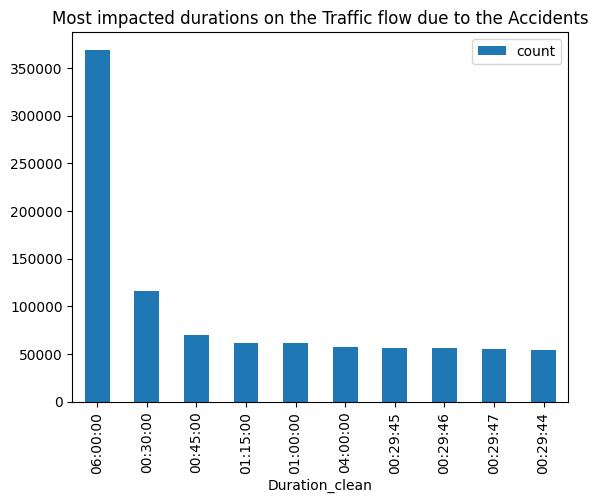

In [25]:
dur_df.head(10).plot(
    kind = 'bar',
    x = 'Duration_clean',
    y = 'count',
    title = 'Most impacted durations on the Traffic flow due to the Accidents'
)

In [26]:
# round(dur_df['count'][0] *100 / sum(dur_df['count']),2)
round(dur_df['count'][0] *100 / df.shape[0],2)

np.float64(4.78)

The majority of road accidents (4.78%) impacted on the traffic flow for 6 hours

## Year

In [27]:
year_df = pd.DataFrame(df.Start_Time.dt.year.value_counts()).reset_index().rename(columns = {'Start_Time':'Year','count':'Cases'}).sort_values(by = 'Year', ascending = True)
year_df.head(7)

,Year,Cases
6,2016,410821
5,2017,718093
4,2018,893426
3,2019,954303
2,2020,1178913
1,2021,1563753
0,2022,1762452


<Axes: title={'center': 'Road accident over the years (2016 - 2023)'}, xlabel='Year'>

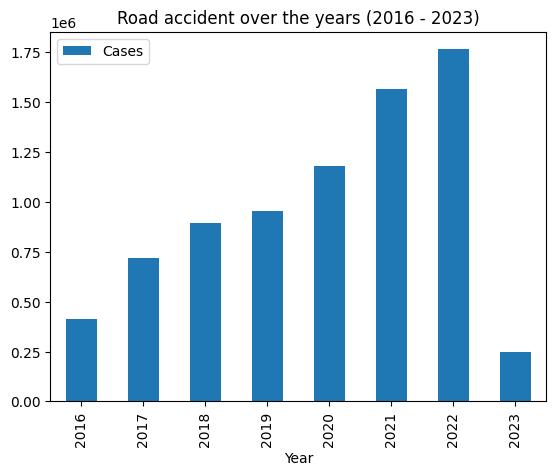

In [28]:
year_df.plot(
    kind = 'bar',
    x = 'Year',
    y = 'Cases',
    title = 'Road accident over the years (2016 - 2023)'
)

In [29]:
for _,row in year_df.iterrows():
    print(row['Year'], round(row['Cases'] * 100 / sum(year_df.Cases),2))

2016 5.32
2017 9.29
2018 11.56
2019 12.35
2020 15.25
2021 20.23
2022 22.8
2023 3.19


In [30]:
year_df.describe()

,Year,Cases
count,8.00000,8.000000e+00
mean,2019.50000,9.660492e+05
std,2.44949,5.250239e+05
min,2016.00000,2.466330e+05
25%,2017.75000,6.412750e+05
50%,2019.50000,9.238645e+05
75%,2021.25000,1.275123e+06
max,2023.00000,1.762452e+06


<p>Accidents was on the rise until 2023
<p>2022 was the most accident prone year with 22.8% of 7 years

## Day

In [31]:
day_df = pd.DataFrame(
    df.Start_Time
    .dt
    .day_name()
    .value_counts(ascending=False)
    ).reset_index().rename(columns={'Start_Time': 'Day','count': 'Cases'})
day_df.head(10)

,Day,Cases
0,Friday,1366499
1,Thursday,1316229
2,Wednesday,1312389
3,Tuesday,1290929
4,Monday,1210921
5,Saturday,668683
6,Sunday,562744


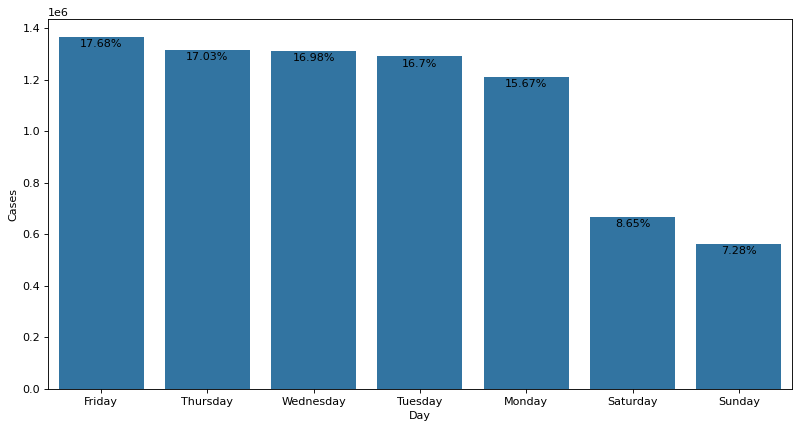

In [32]:
fig, ax = plt.subplots(
    figsize = (12,6),
    dpi = 80
)
ax = sns.barplot(
    x = day_df.Day,
    y = day_df.Cases
)

for i in ax.patches:
    ax.text(
        i.get_x() + i.get_width() / 2,
        i.get_height() - 40000,
        f'{round(i.get_height()*100/df.shape[0],2)}%',
        ha = 'center'
    )

In [33]:
days_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

round(day_df[day_df['Day'].isin(days_order[:4])]['Cases'].sum()
      *100 /
      day_df[day_df['Day'].isin(days_order[-2:])]['Cases'].sum()
      ,2
      )

np.float64(416.63)

<p>Working days accounted for 66.38% of all accidents, over 4 times during the weekends
<p>Only 15.93% of accidents recorded during the weekend
<p>Friday have the highest percentage of road accidents (17.68%)
<p>Sunday is the lowest (7.28%)

## Hour

In [34]:
hour_df = pd.DataFrame(
    df['Start_Time']
    .dt
    .hour
    .value_counts()
).reset_index().rename(
    columns = {
        'Start_Time': 'Hour',
        'count': 'Cases'
    }
)
hour_df.head()

,Hour,Cases
0,7,587472
1,16,581969
2,8,577576
3,17,576015
4,15,525855


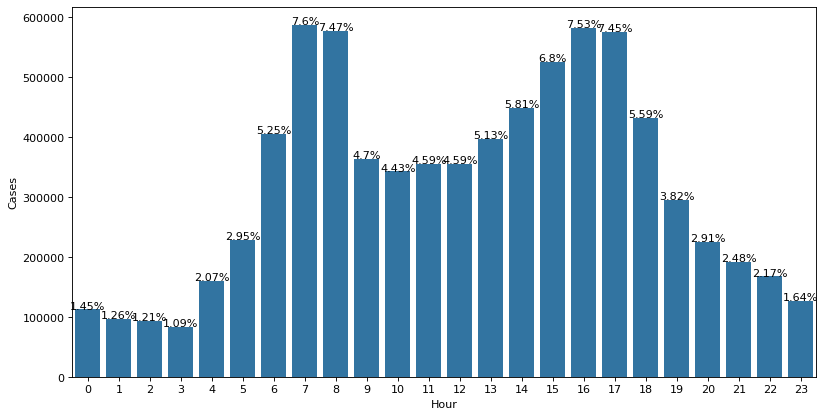

In [35]:
fig, ax = plt.subplots(
    figsize = (12,6),
    dpi = 80
)

ax = sns.barplot(
    data = hour_df,
    x = 'Hour',
    y = 'Cases'
)

for i in ax.patches:
    ax.text(
        i.get_x() + i.get_width() / 2,
        i.get_height()+1000,
        str(round(i.get_height()*100/df.shape[0],2))+'%',
        fontsize = 10,
        ha = 'center',
        color = 'black'
    )

<p>20.32% of road accidents happen during 6:00-8:00
<p>27.37% of road accidents happen during 15:00 - 18:00
<p>Deadliest hours being 7:00-8:00 and 16:00-17:00 implies the rush hours of arriving and returning. Accounted for 30.05% of all accidents

## Road Condition

In [36]:
df[df.columns[-16:-4]].head()

,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False


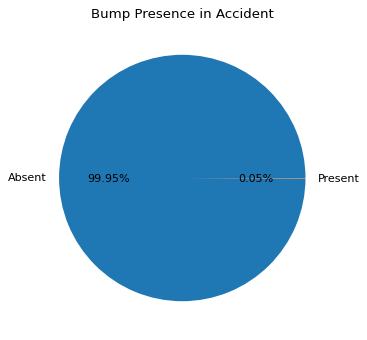

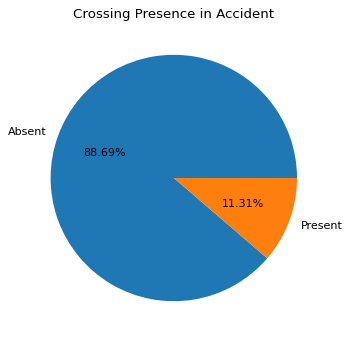

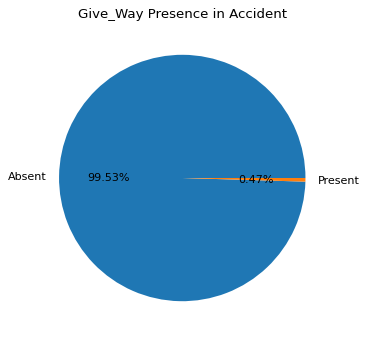

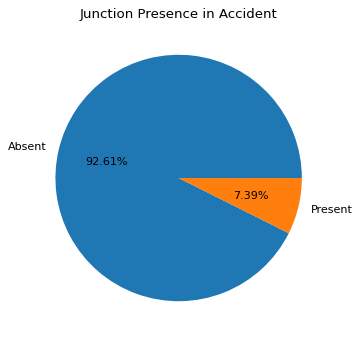

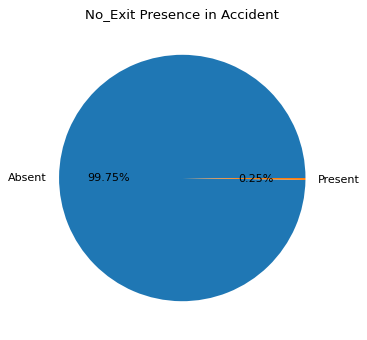

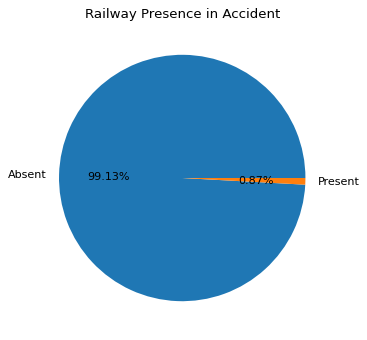

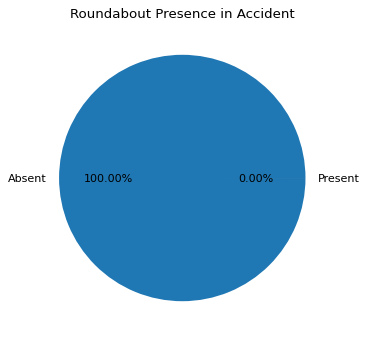

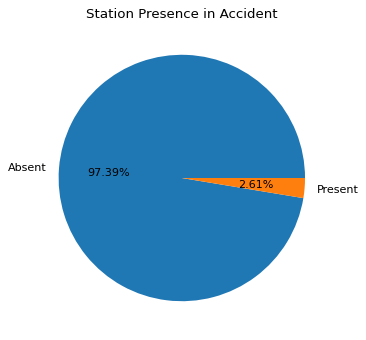

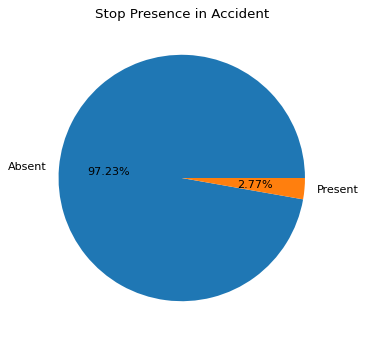

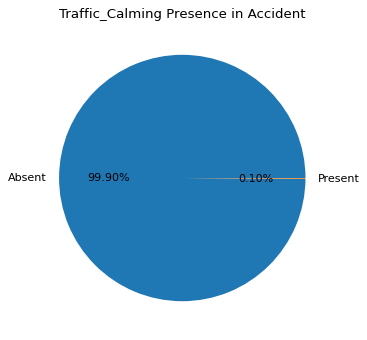

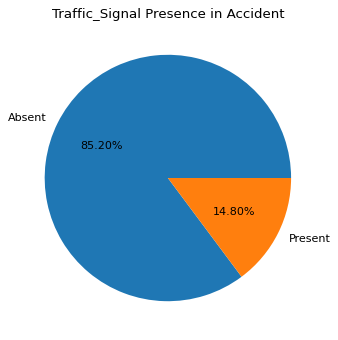

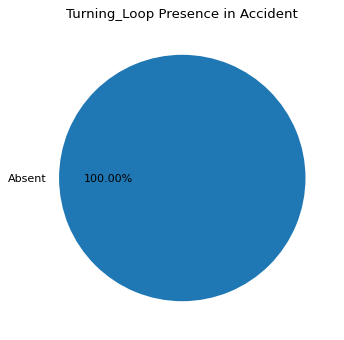

In [37]:
features = [
    'Bump', 'Crossing', 'Give_Way', 'Junction',
    'No_Exit', 'Railway', 'Roundabout', 'Station',
    'Stop', 'Traffic_Calming', 'Traffic_Signal',
    'Turning_Loop'
]
for i in features:
    counts = df[i].value_counts()

    labels = counts.index.map({
        False: 'Absent',
        True: 'Present'
    })

    plt.figure(
        figsize = (5,5),
        dpi=80
    )
    plt.pie(
        counts,
        labels = labels,
        autopct = '%.2f%%',
        # title = i + 'presence in Accidents'
    )
    plt.title(f'{i} Presence in Accident')
    plt.show()

<p> 100% of accidents lack the presence of Turning loop and Roundabout
<p> The most ineffective accident prevention is Traffic light with 14.8% of accident happen in its presence
<p>Bump, Give way, No Exit sign, Traffic Calming was absent in almost every case

In [38]:
df[df.columns[20:29]].head()
# df['Weather_Timestamp'].head()20:29

,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition
0,36.9,NaN,91.0,29.68,10.0,Calm,NaN,0.02,Light Rain
1,37.9,NaN,100.0,29.65,10.0,Calm,NaN,0.00,Light Rain
2,36.0,33.3,100.0,29.67,10.0,SW,3.5,NaN,Overcast
3,35.1,31.0,96.0,29.64,9.0,SW,4.6,NaN,Mostly Cloudy
4,36.0,33.3,89.0,29.65,6.0,SW,3.5,NaN,Mostly Cloudy


In [39]:
df['Weather_Condition'].unique()

<StringArray>
[               'Light Rain',                  'Overcast',
             'Mostly Cloudy',                      'Rain',
                'Light Snow',                      'Haze',
          'Scattered Clouds',             'Partly Cloudy',
                     'Clear',                      'Snow',
 ...
   'Heavy Sleet and Thunder',     'Drifting Snow / Windy',
       'Shallow Fog / Windy',  'Thunder and Hail / Windy',
       'Heavy Sleet / Windy',              'Sand / Windy',
 'Heavy Rain Shower / Windy',       'Blowing Snow Nearby',
         'Heavy Rain Shower',             'Drifting Snow']
Length: 145, dtype: str

In [40]:
condition_df = pd.DataFrame(
    df.Weather_Condition
    .value_counts()
    ).reset_index().rename(
        columns={
            'count':'Cases'
        }
    )

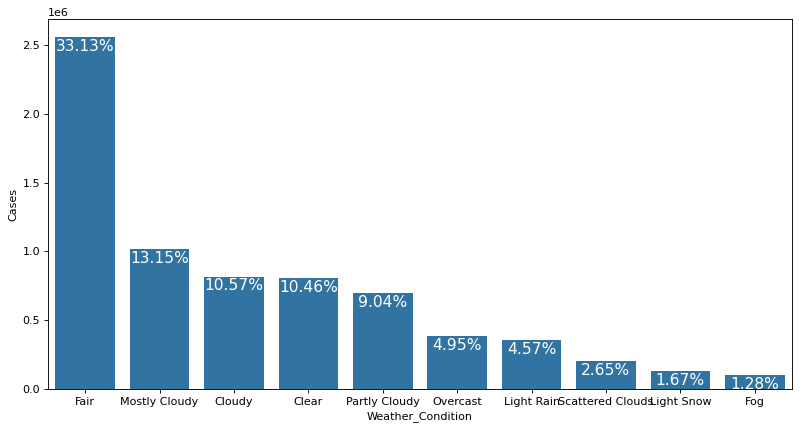

In [41]:
fig, ax = plt.subplots(
    figsize = (12,6),
    dpi = 80
)

ax = sns.barplot(
    data = condition_df.head(10),
    x = 'Weather_Condition',
    y = 'Cases',
)

for i in ax.patches:
    ax.text(
        i.get_x() + i.get_width()/2,
        i.get_height() - 100000,
        str(round(i.get_height() * 100 / df.shape[0],2)) + '%',
        fontsize = 14,
        color = 'white',
        ha = 'center'
    )

In [42]:
def make_bins(attribute, gap):
    min_val = int(attribute.min())
    max_val = int(attribute.max())

    bins = list(range(min_val, max_val + gap, gap))

    labels = [
        f'{bins[i]}:{bins[i+1]}'
        for i in range(len(bins)-1)
    ]

    grouped = pd.cut(
        attribute,
        bins=bins,
        labels=labels,
        include_lowest=True
    )

    grouped_df = (
        grouped
        .value_counts()
        .sort_index()
        .reset_index()
    )

    grouped_df.columns = ['Range', 'Cases']

    return grouped_df

ValueError: Could not interpret value `Farrenheit` for `x`. An entry with this name does not appear in `data`.

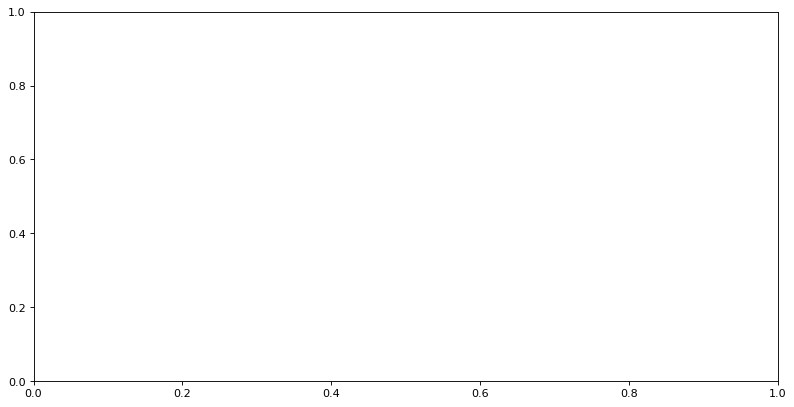

In [43]:
temp_df = make_bins(df['Temperature(F)'],30)
temp_df = temp_df.rename(columns={
        "Temperature(F)":"Farrenheit",
        'count': 'Cases'
    }
)
fig,ax = plt.subplots(
    figsize = (12,6),
    dpi = 80
)

ax = sns.barplot(
    data = temp_df,
    x = 'Farrenheit',
    y = 'Cases'
)

for i in ax.patches:
    ax.text(
        i.get_x() + i.get_width()/2,
        i.get_height()+20000,
        f'{round(i.get_height() * 100 / df.shape[0],2)}%\n{i.get_height()}',
        color = 'black',
        ha = 'center',
        fontsize = 13
    )

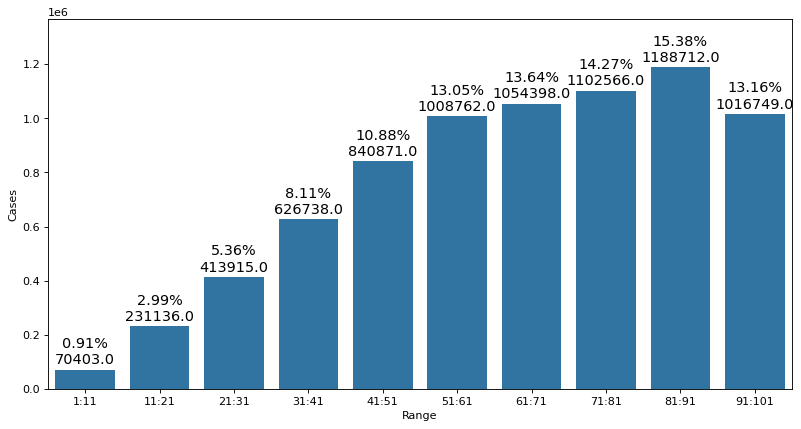

In [ ]:
humid_df = make_bins(df['Humidity(%)'],10)
humid_df = humid_df.rename(
    columns = {
        'count': 'Cases'
    }
)

fig,ax = plt.subplots(
    figsize = (12,6),
    dpi = 80
)

ax.set_ylim(
    0,
    max(humid_df['Cases']) * 1.15
)

ax = sns.barplot(
    data = humid_df,
    x = 'Range',
    y = 'Cases'
)

for i in ax.patches:
    ax.text(
        i.get_x() + i.get_width()/2,
        i.get_height()+20000,
        f'{round(i.get_height() * 100 / df.shape[0],2)}%\n{i.get_height()}',
        color = 'black',
        ha = 'center',
        fontsize = 13
    )

In [60]:
def sns_barplot(data,title):

    fig, ax = plt.subplots(
        figsize=(12,6),
        dpi=80
    )

    ax = sns.barplot(
        data=data,
        x= 'Range',
        y= 'Cases'
    )

    ax.set_ylim(
        0,
        max(data['Cases']) * 1.15
    )

    ax.set_title(
        title,
        fontsize = 18
    )

    for i in ax.patches:

        ax.text(
            i.get_x() + i.get_width()/2,

            i.get_height() + (max(data['Cases']) * 0.02),

            f'{i.get_height() * 100 / df.shape[0]:.2f}%\n{int(i.get_height()):,}',

            color='black',
            ha='center',
            fontsize=13
        )

    plt.show()

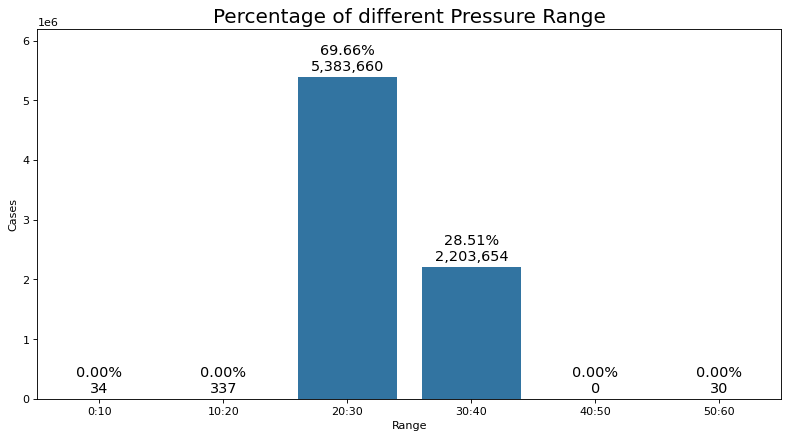

In [ ]:
pressure_df = make_bins(df['Pressure(in)'],10)
pressure_df
sns_barplot(pressure_df,'Range','Cases','Percentage of different Pressure Range')

In [45]:
# series = pd.to_numeric(df['Wind_Speed(mph)'], errors = 'coerce')
# max_val = series.max()
# max_val
df['Wind_Speed(mph)'].max()

np.float64(1087.0)

In [50]:
df['Wind_Speed(mph)'].isna().mean() * 100

np.float64(7.391354529802699)

In [52]:
df['Wind_Speed(mph)'] = df['Wind_Speed(mph)'].fillna(-1)

In [56]:
wind_speed_bin = pd.cut(
    df['Wind_Speed(mph)'],
    bins = [-1,0, 1, 12, 24, 38, max(df['Wind_Speed(mph)'])+0.01],
    labels = [
        'Missing Value',
        'Level 0',
        'Level 1-3',
        'Level 3-5',
        'Level 5-7',
        'Why?'
    ]
)

wind_speed_df = wind_speed_bin.value_counts().reset_index()
wind_speed_df.columns = ['Range', 'Cases']
wind_speed_df['Range'] = pd.Categorical(
    wind_speed_df['Range'],
    categories=[
        'Missing Value',
        'Level 0',
        'Level 1-3',
        'Level 3-5',
        'Level 5-7',
        'Why?'
    ],
    ordered=True
)
wind_speed_df = wind_speed_df.sort_values('Range')
wind_speed_df

,Range,Cases
2,Missing Value,961643
5,Level 0,195
0,Level 1-3,4908411
1,Level 3-5,1241741
3,Level 5-7,43747
4,Why?,1424


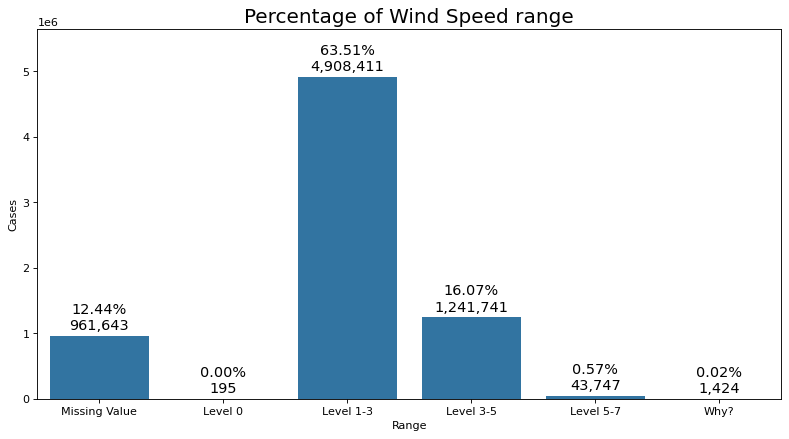

In [61]:
sns_barplot(wind_speed_df,'Percentage of Wind Speed range')

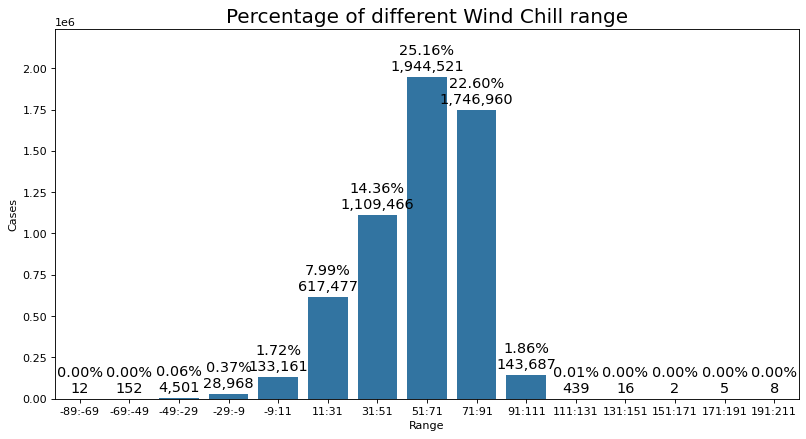

In [62]:
wind_chill_df = make_bins(df['Wind_Chill(F)'], 20)
sns_barplot(wind_chill_df,'Percentage of different Wind Chill range')

In [66]:
df['Visibility(mi)'] = df['Visibility(mi)'].fillna(-1)

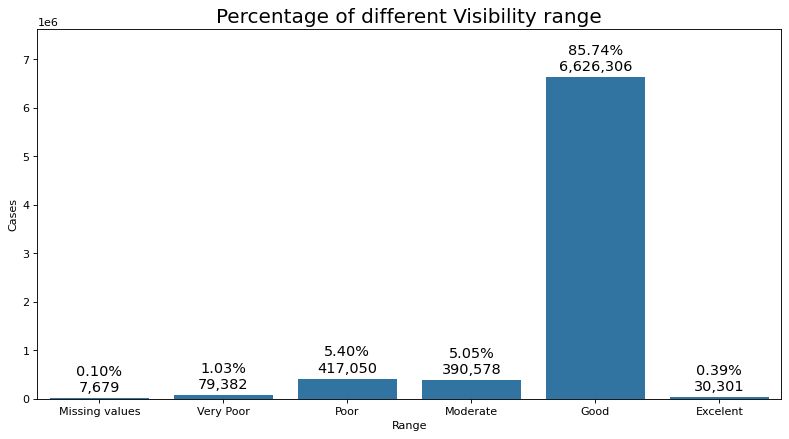

In [71]:
visi_bin = pd.cut(
    df['Visibility(mi)'],
    bins = [-1,0,0.6,3.1,6.2,12.4,max(df['Visibility(mi)'])],
    labels = [
        'Missing values',
        'Very Poor',
        'Poor',
        'Moderate',
        'Good',
        'Excelent'
    ],
    ordered=True
)
visi_df = visi_bin.value_counts().reset_index()
visi_df.columns = ['Range', 'Cases']
visi_df = visi_df.sort_values('Range')

sns_barplot(visi_df,'Percentage of different Visibility range')